<a href="https://colab.research.google.com/github/maps-05/portfolio/blob/main/time_series_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load Dataset

df_class_18 = pd.read_csv("https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/time_series_data_018.csv", index_col='Date', parse_dates=True)
df_class_18

,Value
Date,
2021-01-01,1.000000
2021-01-02,0.901805
2021-01-03,1.104418
2021-01-04,1.056332
2021-01-05,0.957646
...,...
2022-05-11,3.235895
2022-05-12,2.296690
2022-05-13,2.707409


Using Exponential Smoothing, answer the following

1. What is the best model for the time series data.
   A. SES
   B. DES
   C. TES

In [ ]:
# STL Decomposition

from statsmodels.tsa.seasonal import STL

ts_stl = STL(df_class_18["Value"], robust = True)
decomp_stl = ts_stl.fit()

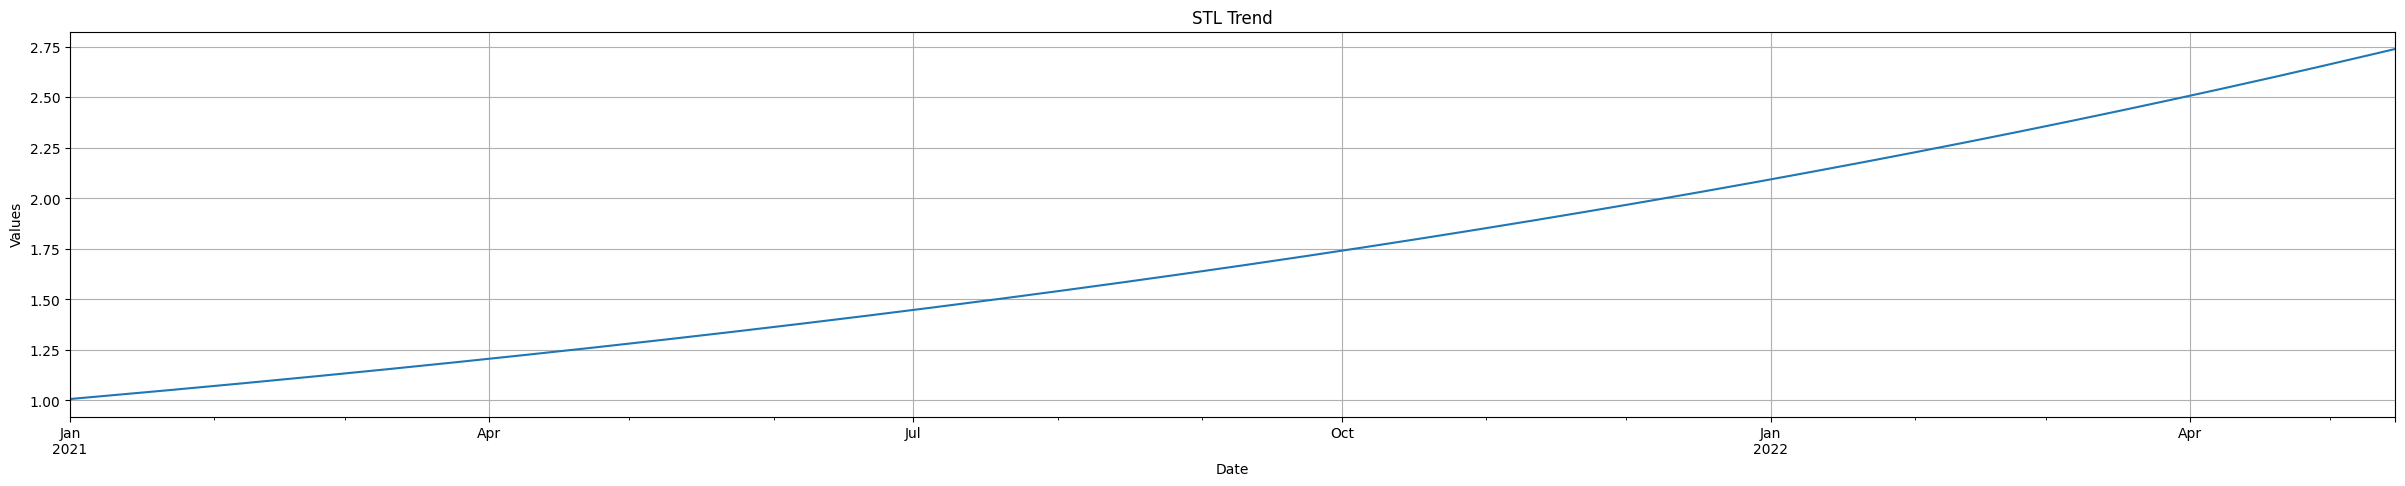

In [ ]:
# STL Trend

decomp_stl.trend.plot(figsize = (30,5), grid = True, ylabel = 'Values', title = 'STL Trend')
plt.show()

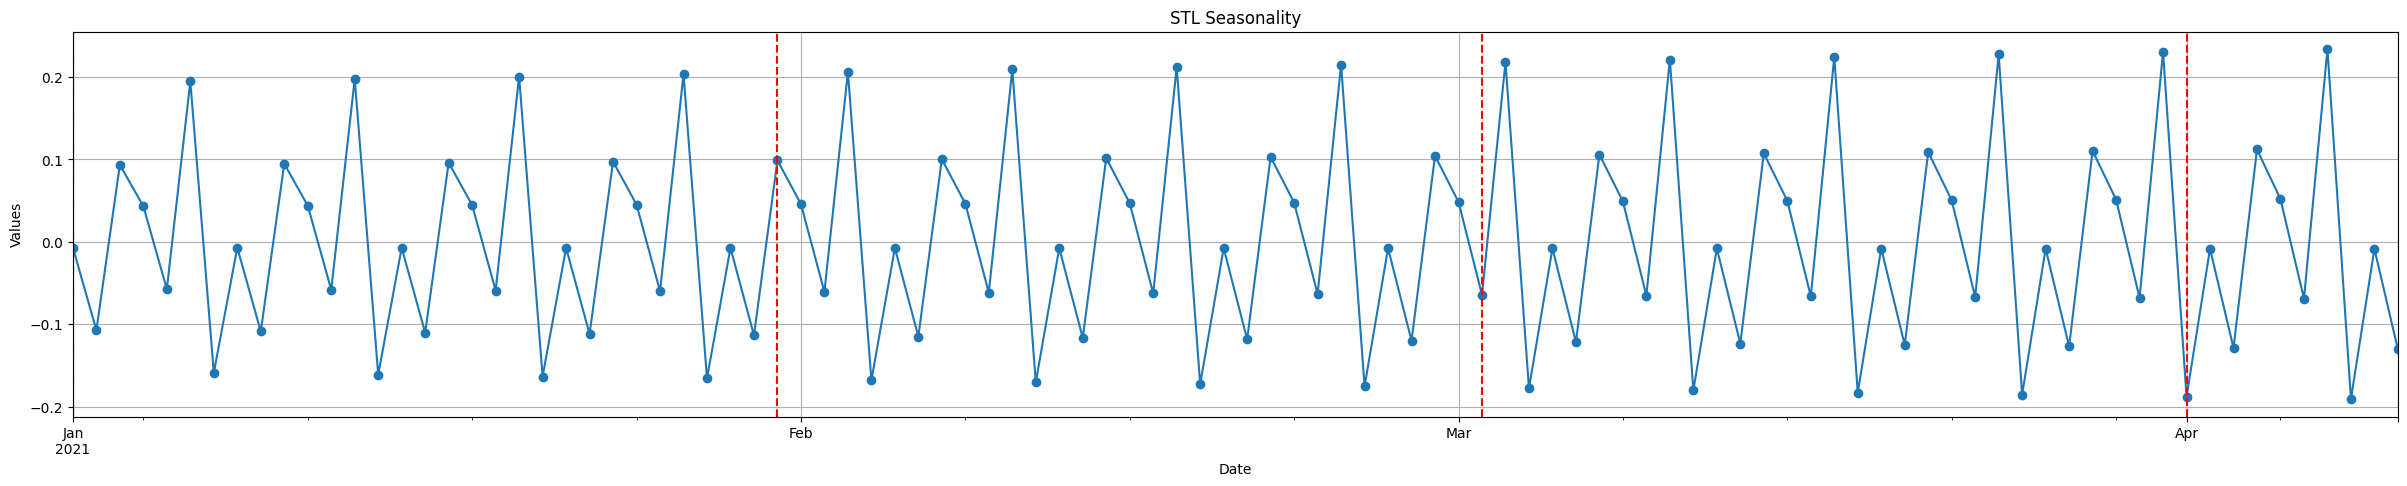

In [ ]:
# STL Seasonality

fig, ax = plt.subplots(figsize=(25, 4))
decomp_stl.seasonal[:100].plot(ax = ax, figsize = (30,5), grid = True, ylabel = 'Values', title = 'STL Seasonality', marker = 'o')

for day in range(0, 100, 30):

 ax.axvline(x = decomp_stl.seasonal.index[day], color = 'red', linestyle = '--')

plt.show()


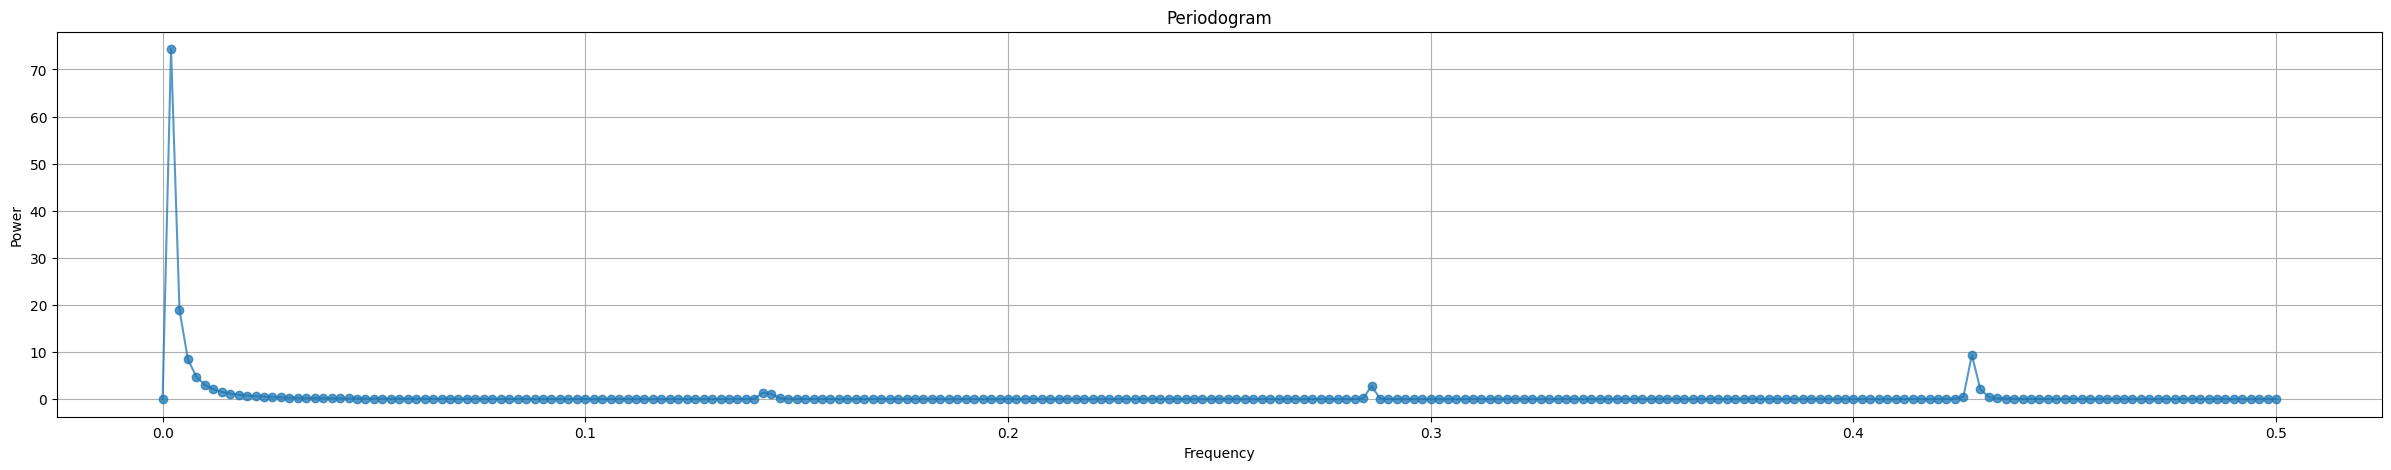

In [ ]:
# Periodogram (for Seasonality)

from scipy.signal import periodogram

frequencies, power = periodogram(df_class_18['Value'])

plt.figure(figsize=(30, 5))
plt.plot(frequencies, power, marker='o', linestyle='-', alpha = 0.75)
plt.title("Periodogram")
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.grid(True)
plt.show()

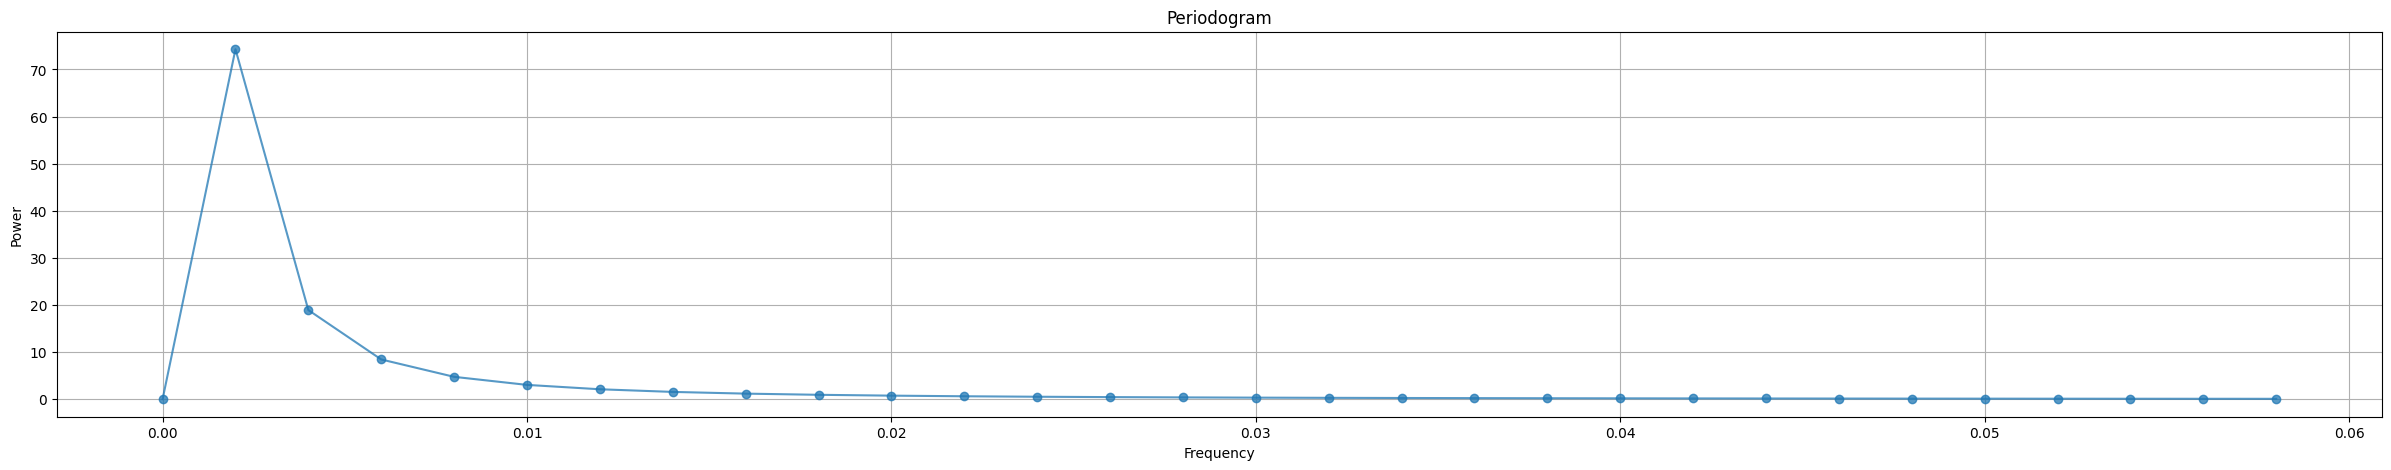

In [ ]:
# Periodogram (for Seasonality)

plt.figure(figsize=(30, 5))
plt.plot(frequencies[:30], power[:30], marker='o', linestyle='-', alpha = 0.75)
plt.title("Periodogram")
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.grid(True)
plt.show()

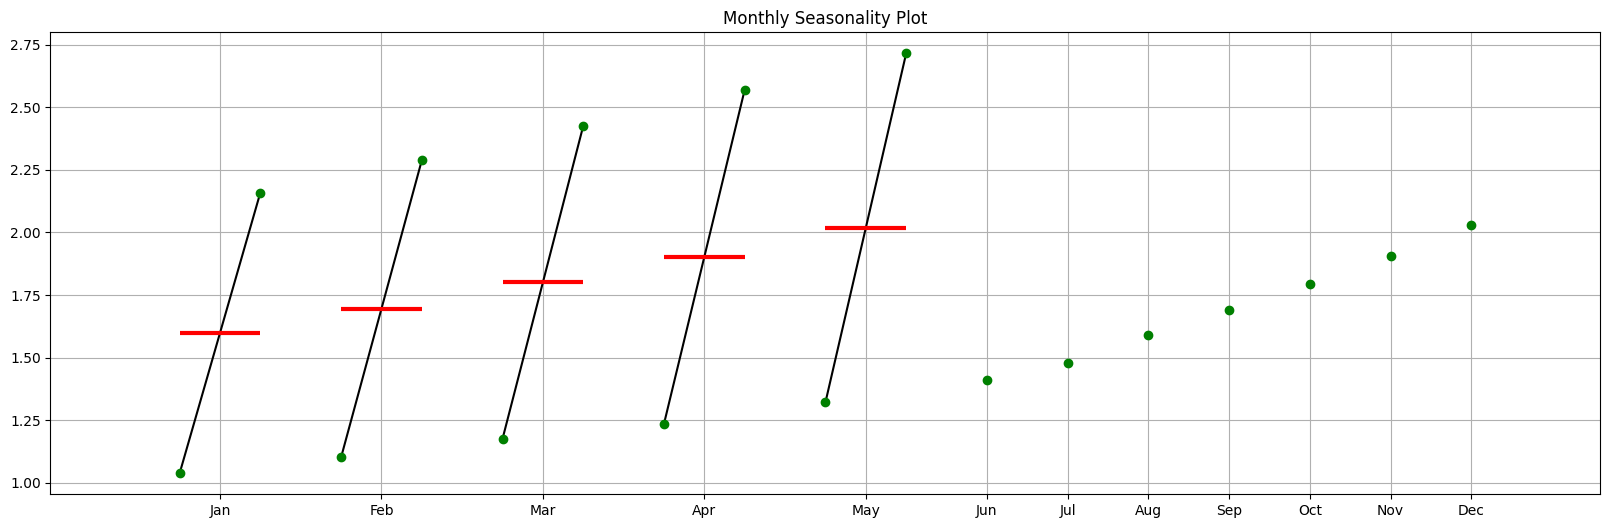

In [ ]:
# Month Plots

from statsmodels.graphics.tsaplots import month_plot

ts_monthly = df_class_18['Value'].resample('MS').mean()

fig, ax = plt.subplots(figsize=(20, 6))
month_plot(ts_monthly, ax = ax)
plt.title("Monthly Seasonality Plot")
plt.grid()

for line in ax.get_lines():

  line.set_marker('o')
  line.set_markerfacecolor('green')
  line.set_markeredgecolor('green')

plt.show()

2. If DES, write the trend category (additive or multiplicative)

If TES, write the trend category (additive or multipicative)

write the seasonal category (additive or multiplicative)

write the optimal seasonal period (3?, 5?, 21?, 30?, etc.)

# WEEK 7

In [ ]:
# We will use Triple Exponential Smoothing

from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
forecast_horizon = 30

train_data = df_class_18.iloc[:-forecast_horizon]
test_data = df_class_18.iloc[-forecast_horizon:]
train_data = train_data.asfreq('D')
test_data = test_data.asfreq('D')

tes_model = ExponentialSmoothing(train_data['Value'], trend = 'multiplicative', seasonal = 'multiplicative', seasonal_periods = 7).fit()
tes_pred = tes_model.forecast(forecast_horizon)
tes_pred

,0
2022-04-16,2.308320
2022-04-17,2.826918
2022-04-18,2.703818
2022-04-19,2.451218
2022-04-20,3.102504
2022-04-21,2.202032
2022-04-22,2.595832
2022-04-23,2.340927
2022-04-24,2.866850
2022-04-25,2.742011


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

print(f'MAE: {mean_absolute_error(test_data, tes_pred)}')
print(f'MSE: {mean_squared_error(test_data, tes_pred)}')
print(f'RMSE: {np.sqrt(mean_squared_error(test_data, tes_pred))}')
print(f'MAP: {mean_absolute_percentage_error(test_data, tes_pred)}')

MAE: 3.087291093852862e-05
MSE: 1.2741670105156851e-09
RMSE: 3.5695476051114445e-05
MAP: 1.1311801558406137e-05


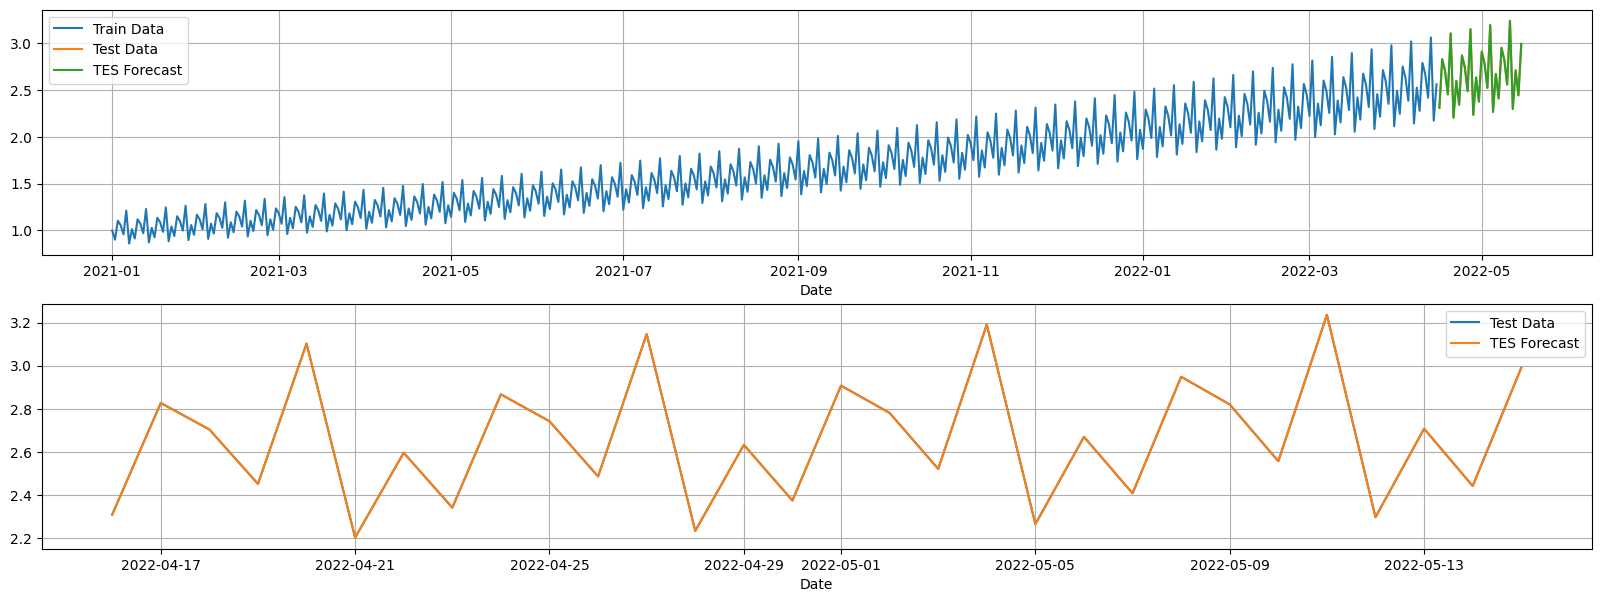

In [ ]:
# Visualization

plt.figure(figsize = (20, 7))

plt.subplot(2, 1, 1)
plt.plot(train_data.index, train_data['Value'], label = 'Train Data')
plt.plot(test_data.index, test_data['Value'], label = 'Test Data')
plt.plot(tes_pred.index, tes_pred, label = 'TES Forecast')
plt.legend()
plt.grid()
plt.xlabel('Date')

plt.subplot(2, 1, 2)
plt.plot(test_data.index, test_data['Value'], label = 'Test Data')
plt.plot(tes_pred.index, tes_pred, label = 'TES Forecast')
plt.legend()
plt.grid()
plt.xlabel('Date')
plt.show()

The forecast at 2022-05-22 is: 3.032299271925167


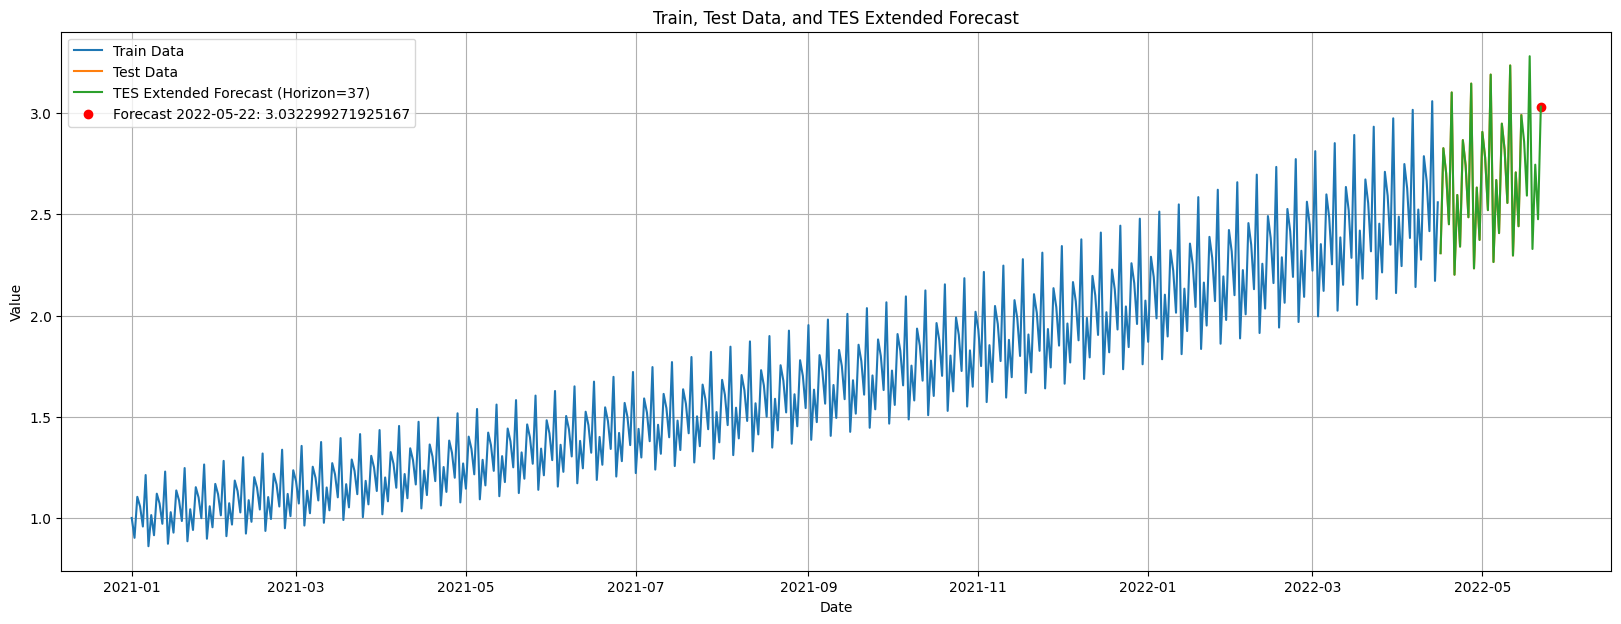

In [ ]:
extended_forecast_horizon = 37
tes_model_for_extended_forecast = ExponentialSmoothing(train_data['Value'], trend = 'mul', seasonal = 'mul', seasonal_periods = 7).fit()
extended_tes_pred = tes_model_for_extended_forecast.forecast(extended_forecast_horizon)

forecast_2022_05_22 = extended_tes_pred['2022-05-22']
print(f"The forecast at 2022-05-22 is: {forecast_2022_05_22}")

# Visualization for the extended forecast
plt.figure(figsize=(20, 7))

plt.plot(train_data.index, train_data['Value'], label='Train Data')
plt.plot(test_data.index, test_data['Value'], label='Test Data')
plt.plot(extended_tes_pred.index, extended_tes_pred, label='TES Extended Forecast (Horizon=37)')
plt.scatter(['2022-05-22'], [forecast_2022_05_22], color='red', marker='o', label=f'Forecast 2022-05-22: {forecast_2022_05_22}')

plt.legend()
plt.grid()
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Train, Test Data, and TES Extended Forecast')
plt.show()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


The forecast at 2022-06-08 is: 3.4226545464558815


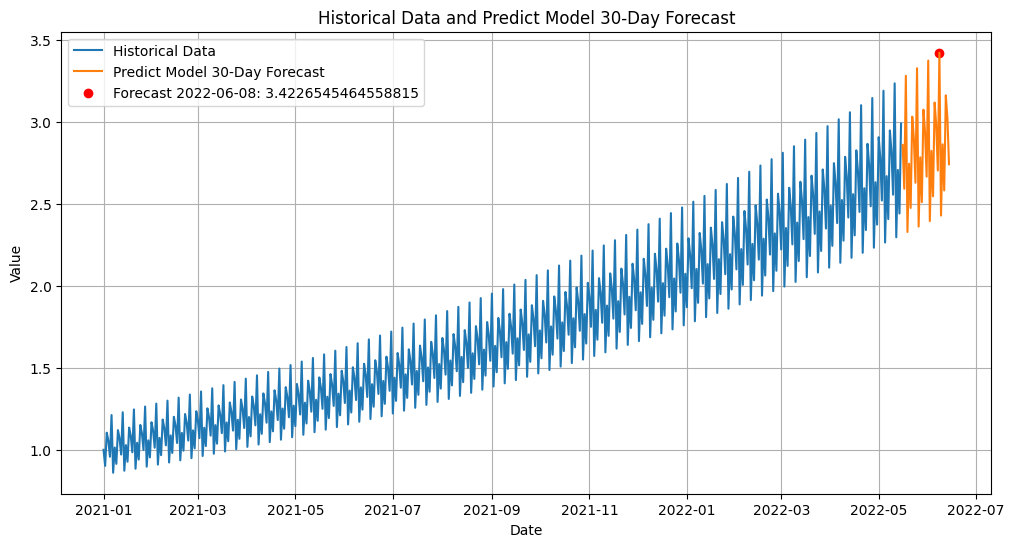

In [ ]:
predict_model = ExponentialSmoothing(df_class_18['Value'], trend='mul', seasonal='mul', seasonal_periods=7)

predict_model_fit = predict_model.fit()

forecast_horizon = 30
df_class_18.index.freq = 'D'
predict_model_forecast = predict_model_fit.forecast(steps=forecast_horizon)

print(f"The forecast at 2022-06-08 is: {forecast_2022_06_08}")

plt.figure(figsize=(12, 6))
plt.plot(df_class_18.index, df_class_18['Value'], label='Historical Data')
plt.plot(predict_model_forecast.index, predict_model_forecast, label='Predict Model 30-Day Forecast')
plt.scatter(['2022-06-08'], [forecast_2022_06_08], color='red', marker='o', label=f'Forecast 2022-06-08: {forecast_2022_06_08}')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Historical Data and Predict Model 30-Day Forecast')
plt.legend()
plt.grid(True)
plt.show()

# WEEK 8

1.
What is the best model for the same time series? A. ARIMA B. SARIMA


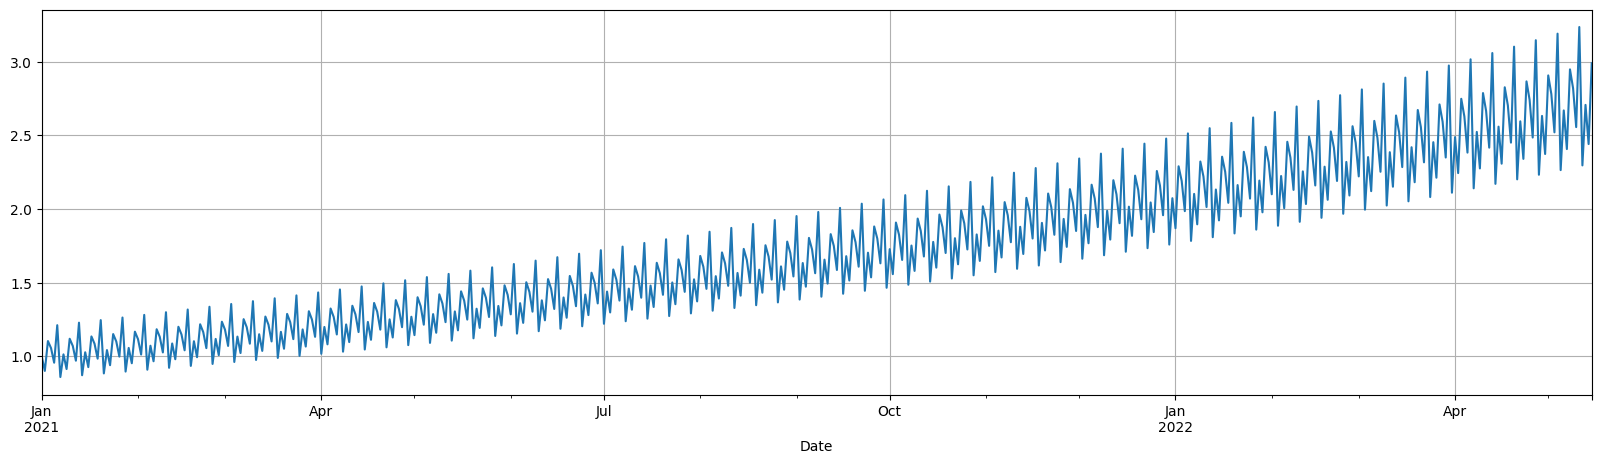

In [ ]:
# Plot

df_class_18['Value'].plot(figsize = (20, 5), grid = True)
plt.show()

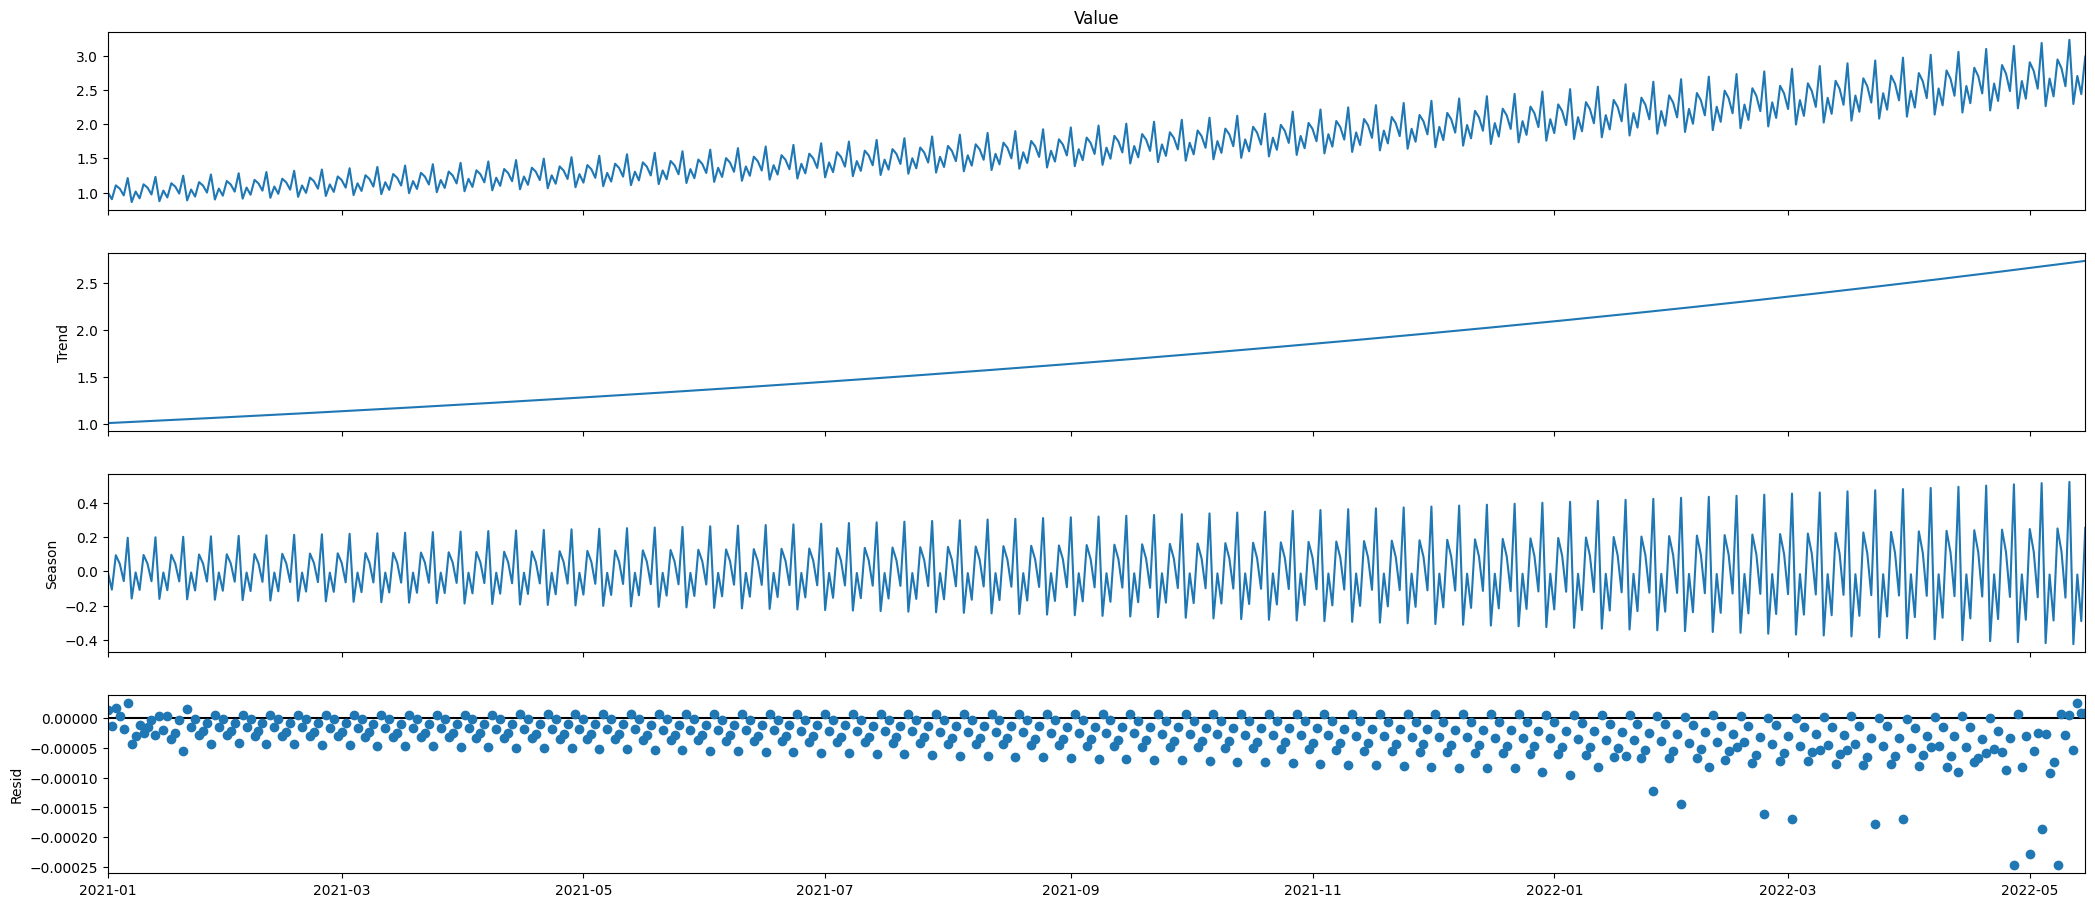

In [ ]:
# STL

from statsmodels.tsa.seasonal import STL

stl = STL(df_class_18['Value'], robust = True)
decomp_stl = stl.fit()

fig = decomp_stl.plot();
fig.set_size_inches(25, 10)
plt.show()

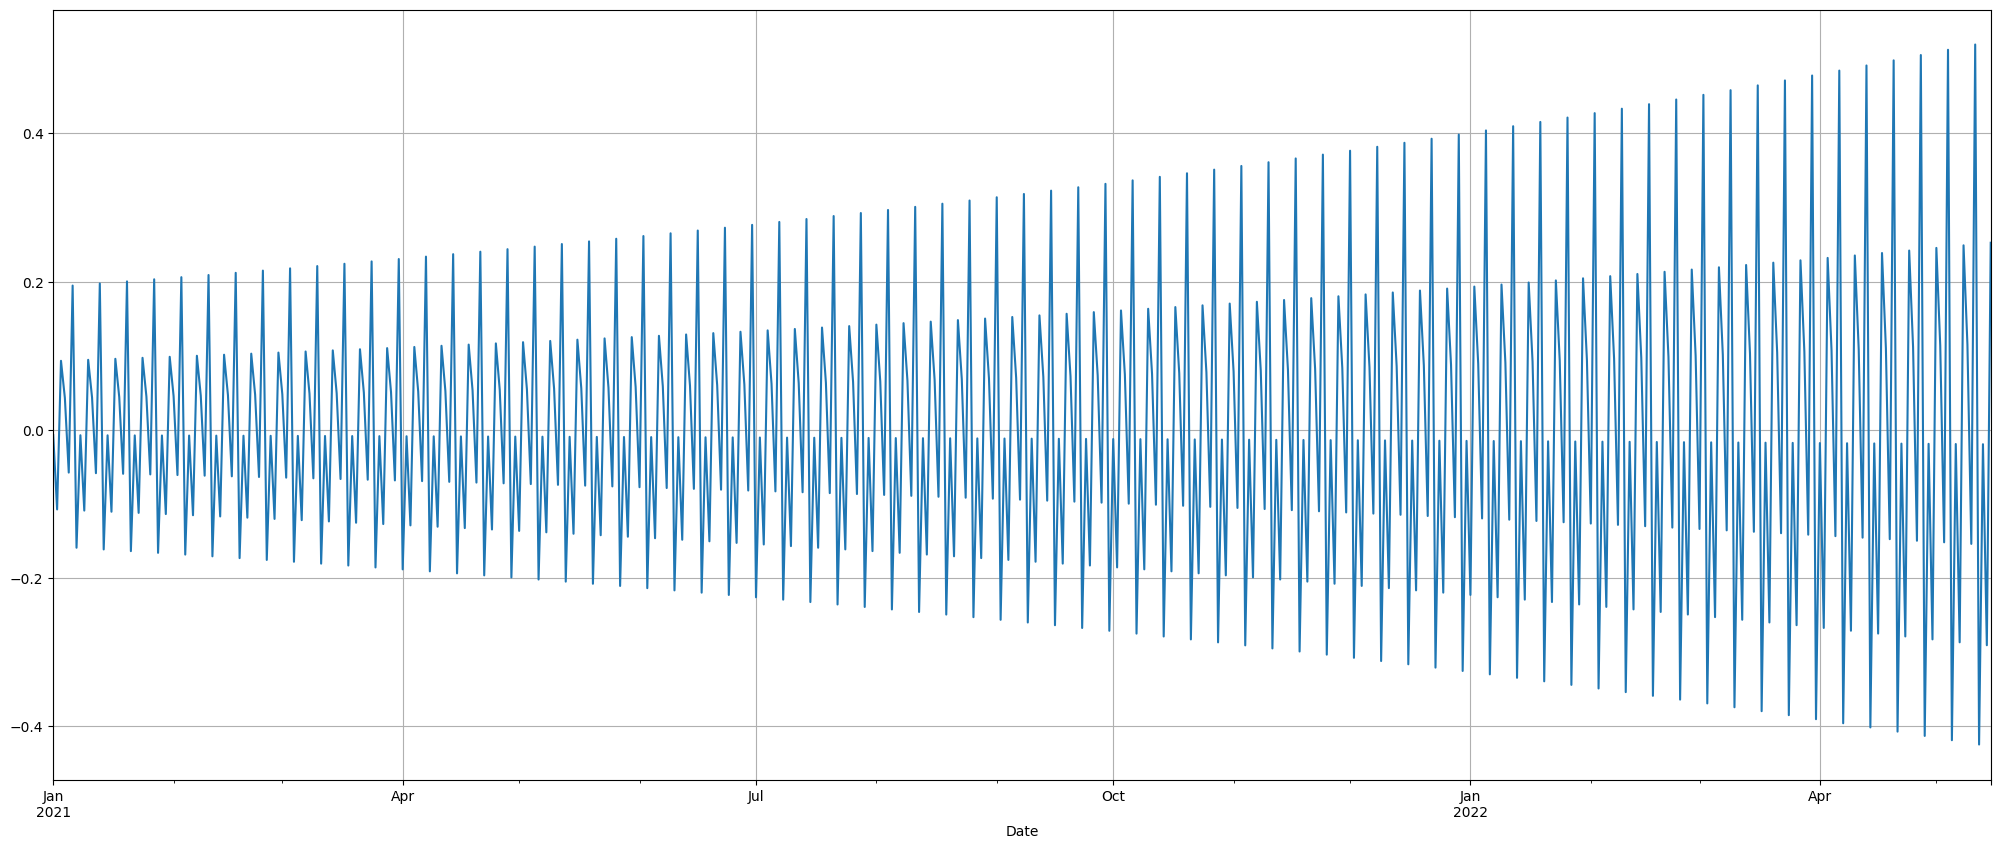

In [ ]:
# Trend, Seasonality, Residual

decomp_stl.seasonal.plot(figsize = (25,10))
plt.grid()
plt.show()

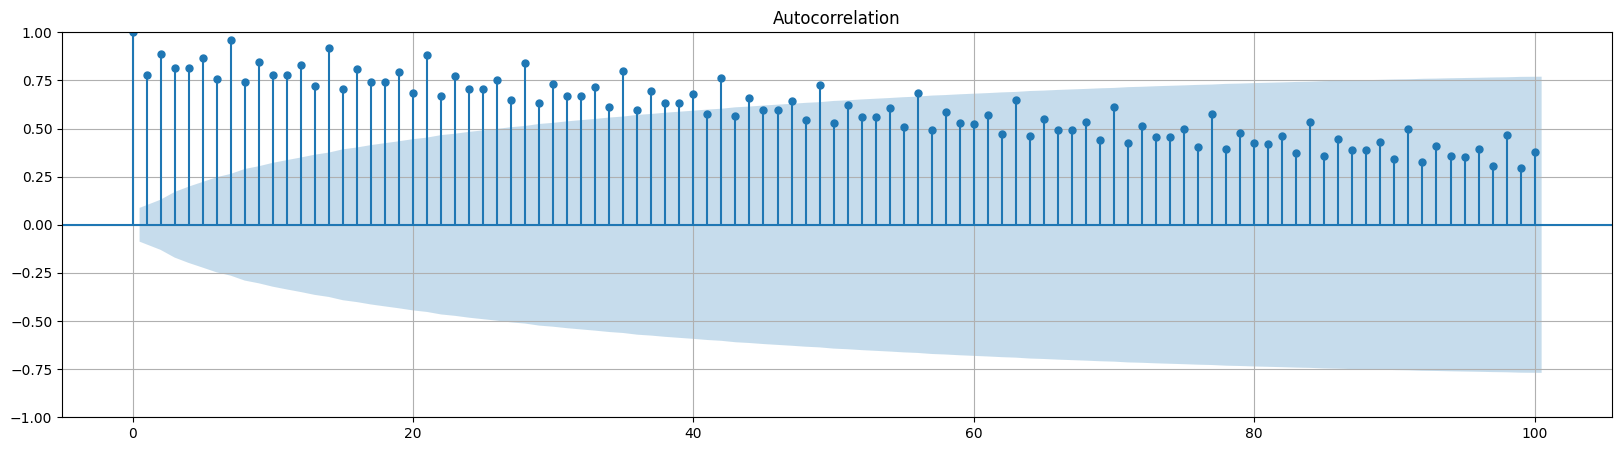

In [ ]:
# ACF

from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(20, 5))
plot_acf(df_class_18['Value'], lags = 100, title='Autocorrelation', ax=ax)
ax.grid(True)
plt.show()

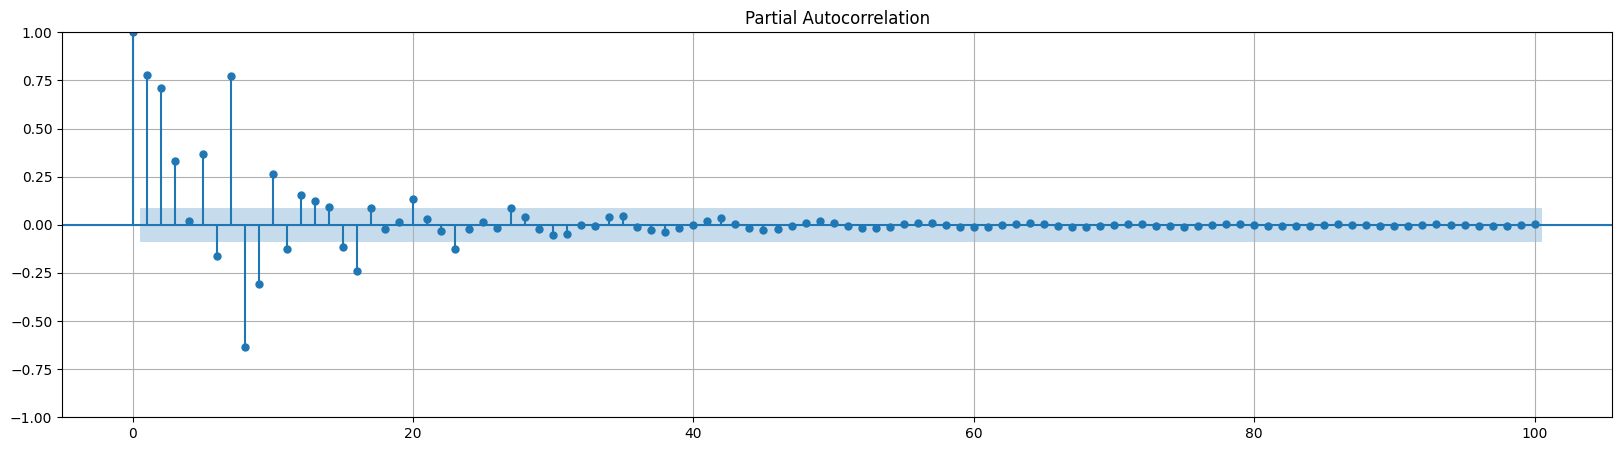

In [ ]:
# PACF

from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(figsize=(20, 5))
plot_pacf(df_class_18['Value'], lags = 100, title='Partial Autocorrelation', ax=ax)
ax.grid(True)
plt.show()

In [ ]:
# Test for Stationarity (>= 0.05 is Non-Stationary, < = 0.05 is Stationary)

from statsmodels.tsa.stattools import adfuller

result = adfuller(df_class_18['Value'])
print(result[1])

1.0


In [ ]:
x = df_class_18['Value'].diff().dropna()

result = adfuller(x)
print(result[1])

1.0


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train = df_class_18[:-30]
test = df_class_18[-30:]

model = SARIMAX(train, order=(1, 1, 0), seasonal_order=(2, 1, [1, 2], 7))
model_fit = model.fit(disp=False)

forecast = model_fit.forecast(steps=30)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


In [ ]:
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)

epsilon = 1e-10
mape = np.mean(np.abs((test['Value'] - forecast) / (test['Value'] + epsilon))) * 100

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 0.0006138595971117766
MSE: 1.0157059137596431e-06
RMSE: 0.0010078223622045916
MAPE: 0.02123942051215065


In [ ]:
# Forecast for 2022-05-22 (30 days ahead)
forecast_may_22 = model_fit.forecast(steps=(pd.to_datetime('2022-05-22') - train.index[-1]).days)
print("Forecast for 2022-05-22:", forecast_may_22)

Forecast for 2022-05-22: 2022-04-16    2.308315
2022-04-17    2.826850
2022-04-18    2.703753
2022-04-19    2.451259
2022-04-20    3.102322
2022-04-21    2.202106
2022-04-22    2.595767
2022-04-23    2.340926
2022-04-24    2.866488
2022-04-25    2.741677
2022-04-26    2.485855
2022-04-27    3.145591
2022-04-28    2.233361
2022-04-29    2.632266
2022-04-30    2.374010
2022-05-01    2.906441
2022-05-02    2.779948
2022-05-03    2.520888
2022-05-04    3.189077
2022-05-05    2.265131
2022-05-06    2.669149
2022-05-07    2.407567
2022-05-08    2.946713
2022-05-09    2.818584
2022-05-10    2.556340
2022-05-11    3.232822
2022-05-12    2.297390
2022-05-13    2.706422
2022-05-14    2.441576
2022-05-15    2.987290
2022-05-16    2.857553
2022-05-17    2.592211
2022-05-18    3.276779
2022-05-19    2.330141
2022-05-20    2.744063
2022-05-21    2.476036
2022-05-22    3.028170
Freq: D, Name: predicted_mean, dtype: float64


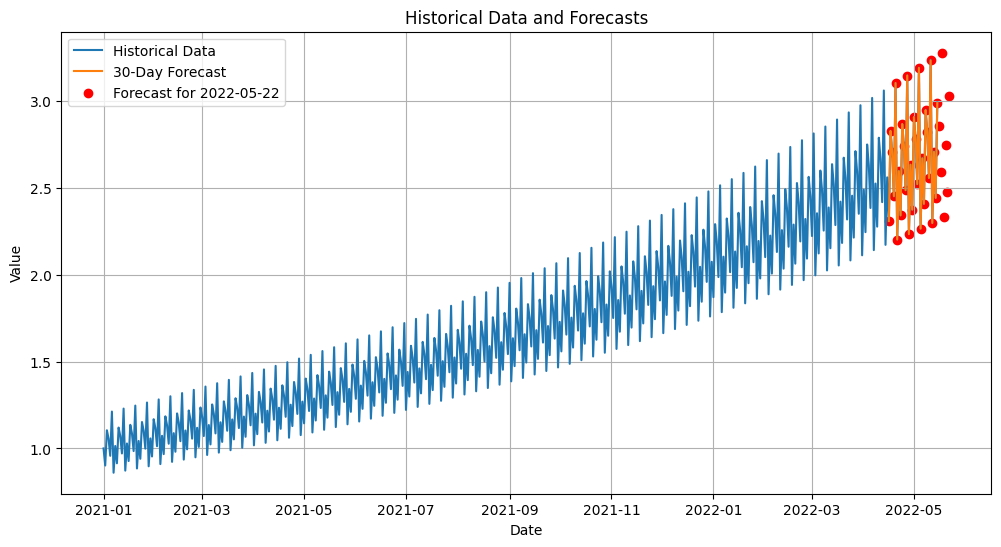

In [ ]:
# Visualization with forecast for 2022-05-22
plt.figure(figsize=(12, 6))
plt.plot(df_class_18.index, df_class_18['Value'], label='Historical Data')
plt.plot(forecast.index, forecast, label='30-Day Forecast')  # Assuming 'forecast' is the 30-day forecast
plt.scatter(forecast_may_22.index, forecast_may_22, color='red', marker='o', label='Forecast for 2022-05-22')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Historical Data and Forecasts')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Forecast for 2022-06-08 (extend forecast to 30 days ahead)
forecast_june_8 = model_fit.forecast(steps=(pd.to_datetime('2022-06-08') - train.index[-1]).days)
print("Forecast for 2022-06-08:", forecast_june_8)

Forecast for 2022-06-08: 2022-04-16    2.308315
2022-04-17    2.826850
2022-04-18    2.703753
2022-04-19    2.451259
2022-04-20    3.102322
2022-04-21    2.202106
2022-04-22    2.595767
2022-04-23    2.340926
2022-04-24    2.866488
2022-04-25    2.741677
2022-04-26    2.485855
2022-04-27    3.145591
2022-04-28    2.233361
2022-04-29    2.632266
2022-04-30    2.374010
2022-05-01    2.906441
2022-05-02    2.779948
2022-05-03    2.520888
2022-05-04    3.189077
2022-05-05    2.265131
2022-05-06    2.669149
2022-05-07    2.407567
2022-05-08    2.946713
2022-05-09    2.818584
2022-05-10    2.556340
2022-05-11    3.232822
2022-05-12    2.297390
2022-05-13    2.706422
2022-05-14    2.441576
2022-05-15    2.987290
2022-05-16    2.857553
2022-05-17    2.592211
2022-05-18    3.276779
2022-05-19    2.330141
2022-05-20    2.744063
2022-05-21    2.476036
2022-05-22    3.028170
2022-05-23    2.896867
2022-05-24    2.628484
2022-05-25    3.320978
2022-05-26    2.363361
2022-05-27    2.782075
2022-05-2

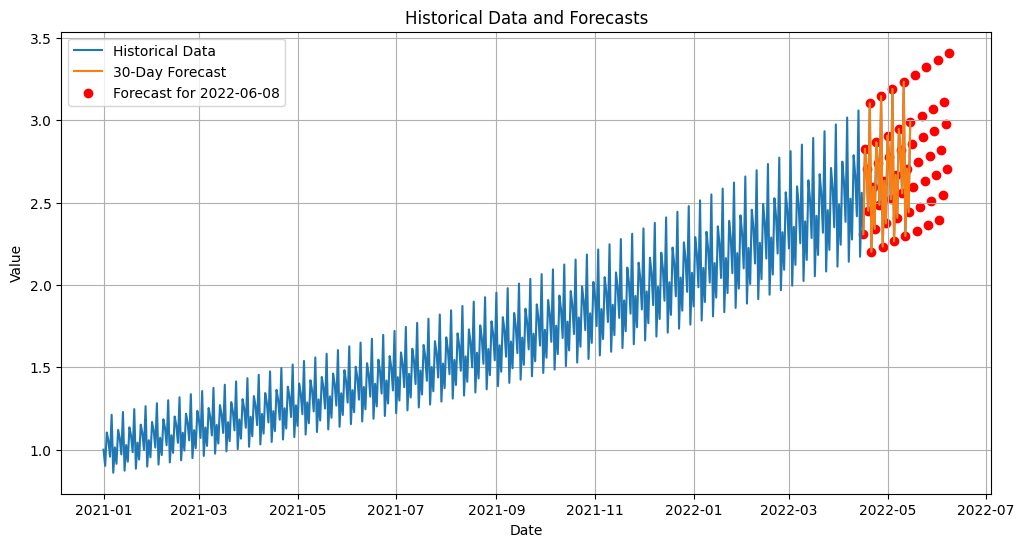

In [ ]:
# Visualization with forecast for 2022-06-08
plt.figure(figsize=(12, 6))
plt.plot(df_class_18.index, df_class_18['Value'], label='Historical Data')
plt.plot(forecast.index, forecast, label='30-Day Forecast')
plt.scatter(forecast_june_8.index, forecast_june_8, color='red', marker='o', label='Forecast for 2022-06-08')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Historical Data and Forecasts')
plt.legend()
plt.grid(True)
plt.show()

Both the Triple Exponential Smoothing (TES) model and the SARIMA model performed exceptionally well in forecasting this time series, largely due to the pronounced weekly seasonality and potentially a strong, predictable trend. The very low error metrics for both models indicate a high degree of accuracy in predicting future values. The TES model slightly outperforms SARIMA in terms of the given error metrics, with values orders of magnitude smaller. This suggests that for this specific dataset, a TES model with multiplicative trend and seasonality of 7 days is an excellent choice for forecasting.